In [1]:
import numpy as np
from skimage import data
import matplotlib.pyplot as plt
from skimage.exposure import rescale_intensity
from skimage.morphology import reconstruction

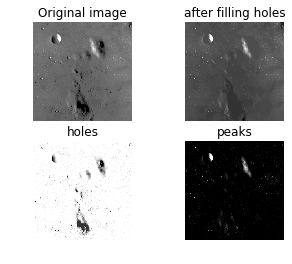

In [6]:
image = data.moon()

# Rescale image intensity so that we can see dim features.
image = rescale_intensity(image,
                         in_range=(50, 200))
mask = image

seed = np.copy(image)
seed[1:-1, 1:-1] = image.max()

filled = reconstruction(seed, mask,
                       method='erosion')

seed = np.copy(image)
seed[1:-1, 1:-1] = image.min()

rec = reconstruction(seed, mask,
                    method='dilation')

fig, ax = plt.subplots(2, 2, figsize=(5, 4), sharex=True, sharey=True)
ax = ax.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(filled, cmap='gray')
ax[1].set_title('after filling holes')
ax[1].axis('off')

ax[2].imshow(image - filled, cmap='gray')
ax[2].set_title('holes')
ax[2].axis('off')

ax[3].imshow(image - rec, cmap='gray')
ax[3].set_title('peaks')
ax[3].axis('off')
plt.show()